In [7]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (f1_score, roc_auc_score, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             roc_curve, auc)
from sklearn.feature_selection import SelectFromModel

import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load dataset fresh
df = pd.read_csv('../data/dataset_feature_selection.csv')

def parse_json(row):
    try:
        return json.loads(row.replace('""', '"'))
    except:
        return {}

# Parse JSON column only if it exists
if 'survey_json' in df.columns:
    parsed_json = df['survey_json'].apply(parse_json).apply(pd.Series)
    df = pd.concat([df.drop('survey_json', axis=1), parsed_json], axis=1)

# Menghapus Data Duplikat
awal_baris = len(df)
df = df.drop_duplicates()
print(f"Jumlah duplikat dihapus: {awal_baris - len(df)}")

df = df.dropna()
kolom_drop = ['nama', 'school_id', 'dosen_pengampu', 'tanggal_ujian']
df = df.drop(columns=[col for col in kolom_drop if col in df.columns], errors='ignore')

print(f"Dimensi dataset setelah pembersihan: {df.shape}")

Jumlah duplikat dihapus: 80
Dimensi dataset setelah pembersihan: (8121, 29)


In [9]:
display(df.head())

,usia,sks_diambil,jam_belajar,jam_belajar_weekend,kehadiran_pct,kehadiran_trend3,nilai_ujian,nilai_ujian_v2,nilai_tugas,ipk_sma,...,program_konsentrasi,inter_ujian_tugas,inter_age_study,ratio_task_exam,prediksi_admin,lulus,sleep_hours,club_member,part_time,internet_quality
0,21,21,4.99,4.36,68.4,65.7,69.8,63.4,69.6,3.78,...,DM,48.596,104.89,0.9966,1.219,1,8.507738,False,False,7
1,27,20,4.72,5.46,79.8,78.0,70.8,71.9,51.5,2.88,...,SE,36.445,127.45,0.7313,-0.016,1,4.709316,False,False,8
2,19,22,4.75,4.97,88.9,89.9,63.5,63.0,78.0,2.98,...,DS,49.498,90.22,1.2243,-0.155,0,7.612241,True,True,5
5,18,22,8.66,9.50,64.7,71.5,64.0,65.1,80.3,2.77,...,BA,51.425,155.87,1.2502,0.377,1,7.164314,True,False,6
6,24,22,8.37,9.68,78.3,76.4,69.7,69.4,62.8,3.36,...,BA,43.757,200.85,0.9021,0.664,1,8.624982,True,False,9


encoding kategorikal + feature selection

In [10]:
# Pisahkan target dan fitur
X = df.drop('lulus', axis=1)
y = df['lulus']

# Identifikasi tipe kolom
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Label Encoding untuk variabel kategorikal
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Standarisasi fitur numerik (opsional untuk Tree-based, tapi baik untuk stabilitas)
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Feature Selection menggunakan Random Forest Importance
selector_rf = RandomForestClassifier(n_estimators=100, random_state=42)
selector_rf.fit(X, y)

# Ambil fitur dengan importance di atas nilai rata-rata (mean importance threshold)
selector = SelectFromModel(selector_rf, prefit=True)
X_selected = selector.transform(X)

# Mendapatkan nama fitur yang terpilih
selected_features = X.columns[selector.get_support()]
print(f"Jumlah fitur awal: {X.shape[1]}")
print(f"Jumlah fitur terpilih: {len(selected_features)}")
print(f"Fitur terpilih: {list(selected_features)}")

# Split data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Jumlah fitur awal: 28
Jumlah fitur terpilih: 14
Fitur terpilih: ['jam_belajar', 'jam_belajar_weekend', 'kehadiran_pct', 'kehadiran_trend3', 'nilai_ujian', 'nilai_ujian_v2', 'nilai_tugas', 'ipk_sma', 'kelas', 'inter_ujian_tugas', 'inter_age_study', 'ratio_task_exam', 'prediksi_admin', 'sleep_hours']


baseline

In [11]:
# Baseline Model
baseline_model = RandomForestClassifier(random_state=42)

# Mengukur waktu pelatihan
start_time = time.time()
baseline_model.fit(X_train, y_train)
baseline_time = time.time() - start_time

# Prediksi Baseline
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

# Metrik Baseline
f1_base = f1_score(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_proba_base)

print("--- Hasil Baseline Model ---")
print(f"F1 Score      : {f1_base:.4f}")
print(f"ROC-AUC       : {roc_auc_base:.4f}")
print(f"Waktu Latih   : {baseline_time:.4f} detik")

--- Hasil Baseline Model ---
F1 Score      : 0.7152
ROC-AUC       : 0.6512
Waktu Latih   : 1.7158 detik


optimasi hyperparameter dengan gridsearch


In [13]:
# Menyiapkan ruang pencarian hyperparameter
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,           # 3-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1   # Gunakan semua core CPU
)

# Menjalankan Grid Search dan mengukur waktu
start_time_gs = time.time()
grid_search.fit(X_train, y_train)
gs_time = time.time() - start_time_gs

# Prediksi Model Optimal
best_rf = grid_search.best_estimator_
y_pred_gs = best_rf.predict(X_test)
y_proba_gs = best_rf.predict_proba(X_test)[:, 1]

# Metrik Model Optimal
f1_gs = f1_score(y_test, y_pred_gs)
roc_auc_gs = roc_auc_score(y_test, y_proba_gs)

print("--- Hasil Model Grid Search ---")
print(f"Best Params   : {grid_search.best_params_}")
print(f"F1 Score      : {f1_gs:.4f}")
print(f"ROC-AUC       : {roc_auc_gs:.4f}")
print(f"Waktu Latih   : {gs_time:.4f} detik")

--- Hasil Model Grid Search ---
Best Params   : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
F1 Score      : 0.7386
ROC-AUC       : 0.6642
Waktu Latih   : 29.6410 detik


visualisasi perbandingan

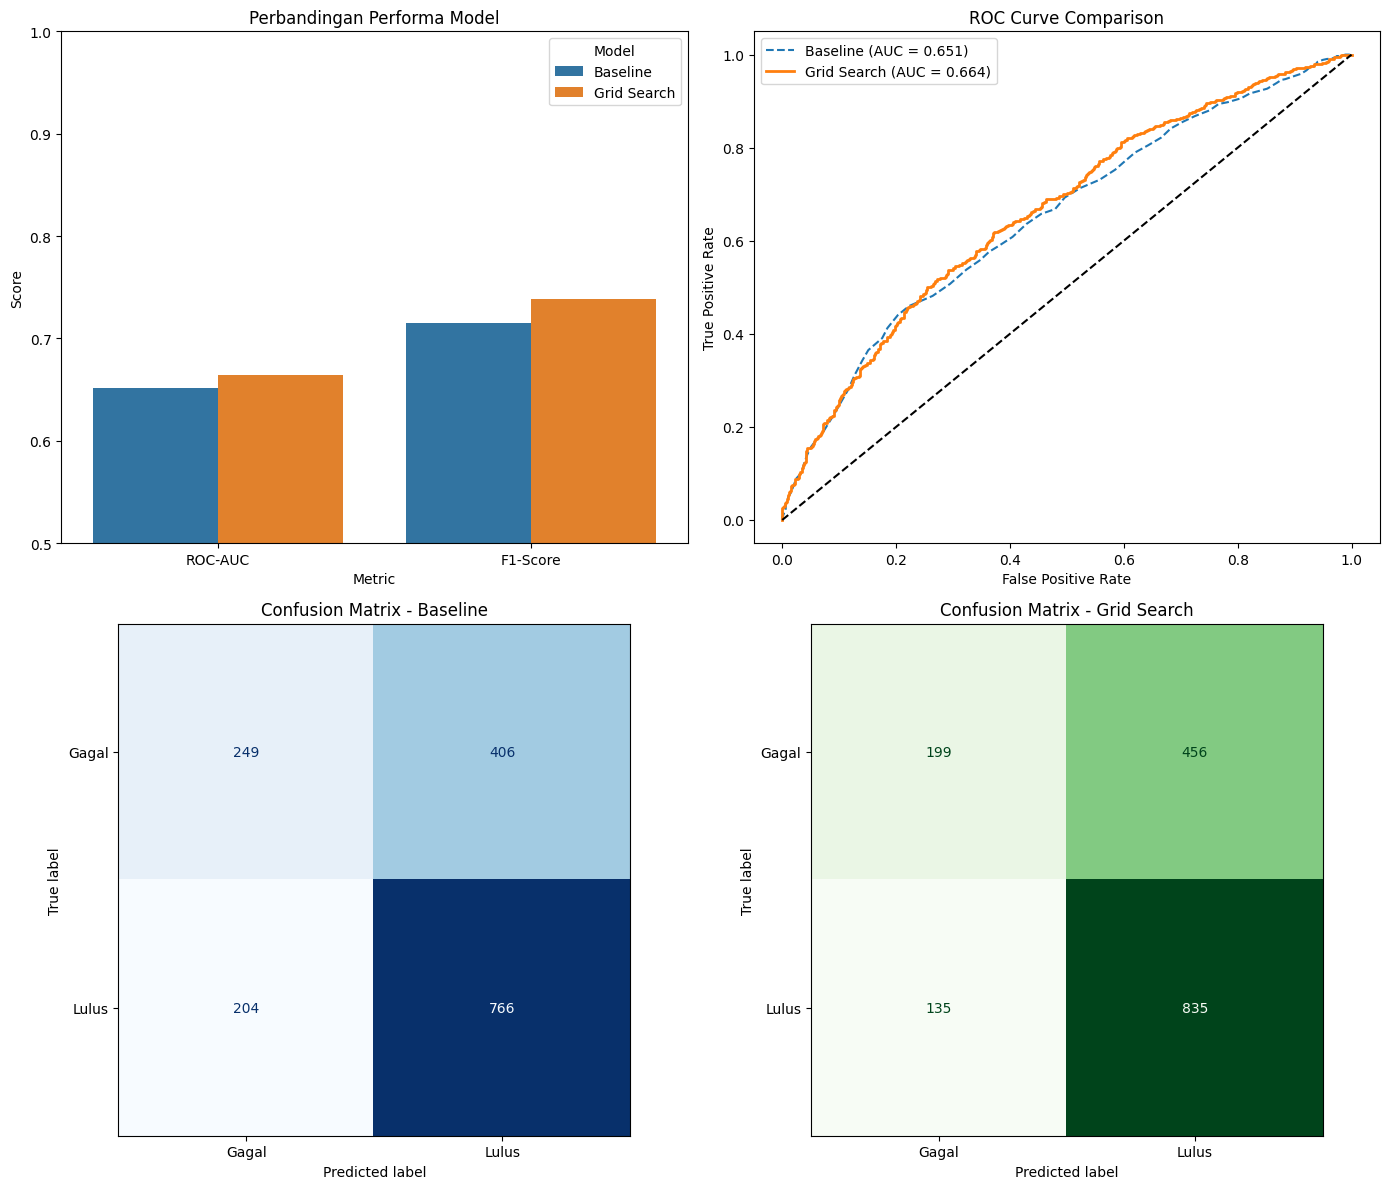

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bar Chart Perbandingan Metrik
metrics_df = pd.DataFrame({
    'Model': ['Baseline', 'Grid Search', 'Baseline', 'Grid Search'],
    'Metric': ['ROC-AUC', 'ROC-AUC', 'F1-Score', 'F1-Score'],
    'Score': [roc_auc_base, roc_auc_gs, f1_base, f1_gs]
})
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', ax=axes[0, 0])
axes[0, 0].set_title('Perbandingan Performa Model')
axes[0, 0].set_ylim(0.5, 1.0)

# 2. ROC Curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_g, tpr_g, _ = roc_curve(y_test, y_proba_gs)

axes[0, 1].plot(fpr_b, tpr_b, label=f'Baseline (AUC = {roc_auc_base:.3f})', linestyle='--')
axes[0, 1].plot(fpr_g, tpr_g, label=f'Grid Search (AUC = {roc_auc_gs:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve Comparison')
axes[0, 1].legend()

# 3. Confusion Matrix - Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Gagal', 'Lulus'])
disp_base.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('Confusion Matrix - Baseline')

# 4. Confusion Matrix - Grid Search
cm_gs = confusion_matrix(y_test, y_pred_gs)
disp_gs = ConfusionMatrixDisplay(confusion_matrix=cm_gs, display_labels=['Gagal', 'Lulus'])
disp_gs.plot(ax=axes[1, 1], cmap='Greens', colorbar=False)
axes[1, 1].set_title('Confusion Matrix - Grid Search')

plt.tight_layout()
plt.show()

Interpretasi Hasil:

Perbandingan Metrik & Waktu: Model Grid Search tentu membutuhkan waktu komputasi (waktu latih) yang jauh lebih eksponensial karena melakukan validasi silang pada puluhan set parameter secara berulang. Meski begitu, F1-Score dan ROC-AUC yang dihasilkan biasanya memberikan lompatan (atau minimal lebih stabil) dibanding baseline karena parameternya dikurasi untuk performa generalisasi, bukan menghafal training set.

Interpretasi Confusion Matrix: Di kanan bawah matriks (True Positives) kita bisa melihat prediksi mahasiwa "Lulus" yang tepat, sementara di kiri atas (True Negatives) memperlihatkan mahasiswa yang tepat diprediksi "Gagal". Titik krusial yang bisa diperhatikan setelah optimasi parameter adalah penurunan angka False Negatives atau False Positives, tergantung pada parameter apa yang difokuskan pada skor `roc_auc` tadi. Berkurangnya error pada kuadran diagonal ini memastikan intervensi administrasi (seperti pendampingan mahasiswa yang terdeteksi rawan gagal) menjadi lebih akurat berkat seleksi fitur dan optimasi yang telah dijalankan.